In [9]:
import pandas as pd
import matplotlib.pyplot as plt



========== EMPLOYEE DATA ==========
  Employee_ID Employee_Name Department  Performance  Attendance
0        E001  Aarav Sharma         IT           92          96
1        E002   Priya Verma         HR           78          88
2        E003   Rohan Mehta    Finance           85          91
3        E004    Neha Gupta  Marketing           73          72
4        E005   Simran Kaur         IT           95          98

Dataset Shape: (30, 5)

Columns:
['Employee_ID', 'Employee_Name', 'Department', 'Performance', 'Attendance']

========== DATA CLEANING ==========

Missing values:
Employee_ID      0
Employee_Name    0
Department       0
Performance      0
Attendance       0
dtype: int64

Duplicate records: 0

Data after cleaning:
  Employee_ID Employee_Name Department  Performance  Attendance
0        E001  Aarav Sharma         IT           92          96
1        E002   Priya Verma         HR           78          88
2        E003   Rohan Mehta    Finance           85          91
3      

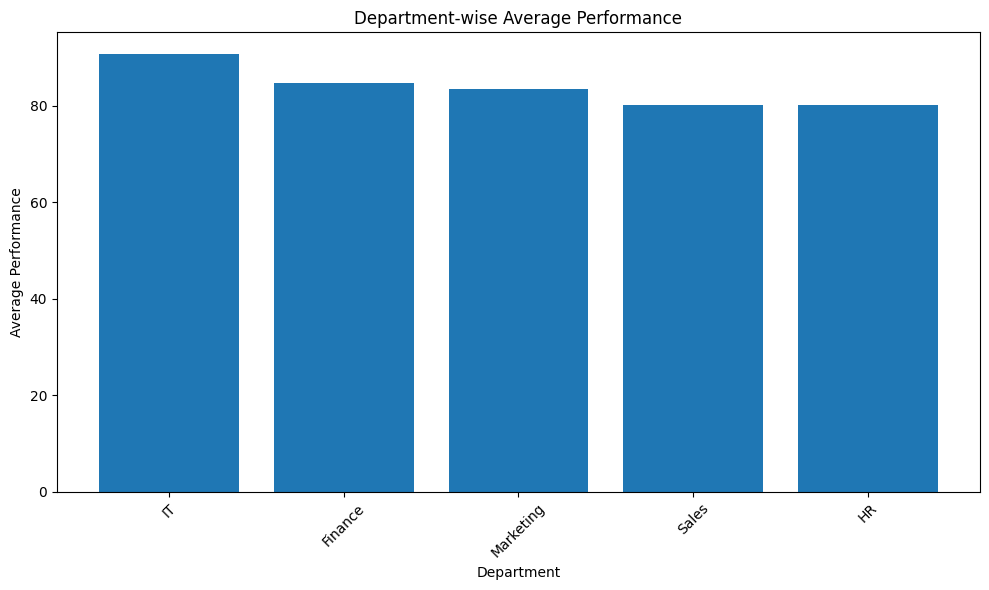

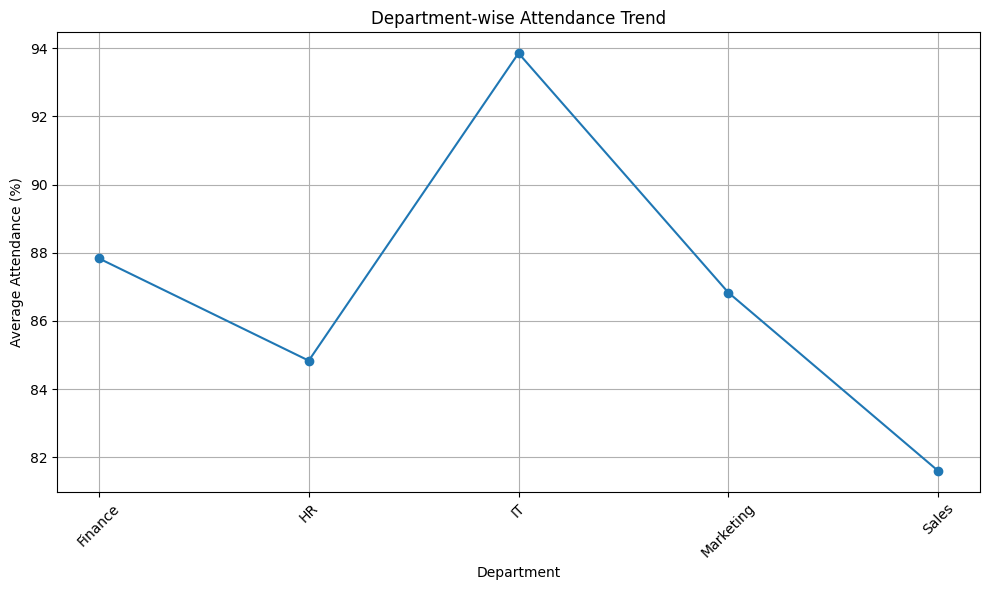

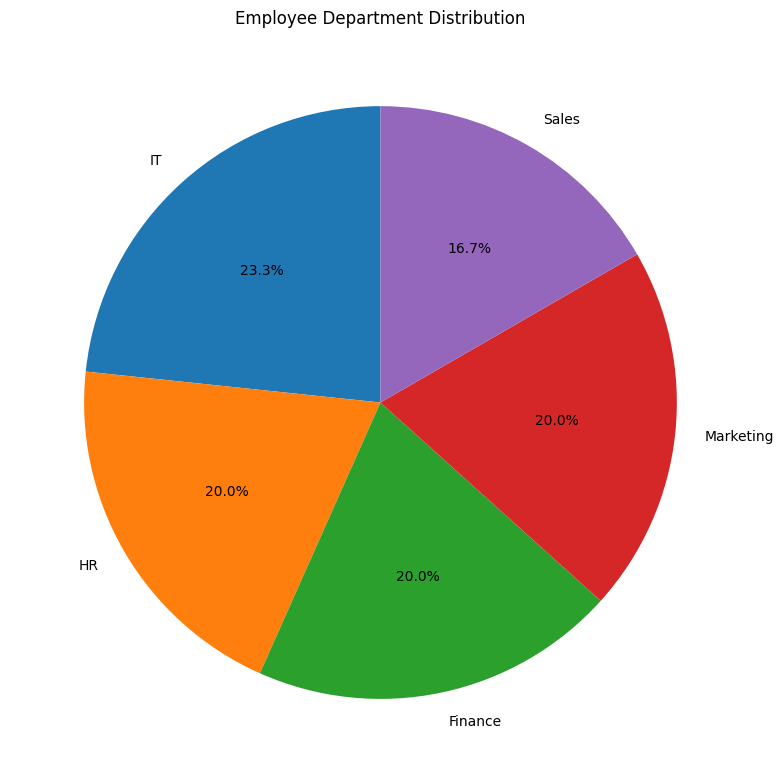


========== CREATING FINAL REPORT ==========

Final report exported successfully!

File: final_employee_report.csv

========== PROJECT SUMMARY ==========
Total Employees: 30
Average Performance: 84.2
Average Attendance: 87.4 %
Employees below 75% attendance: 5
Best Department: IT
Highest Performer: Riya Kapoor

========== PROJECT COMPLETED ==========


In [13]:
df = pd.read_csv("employee_data.csv")

print("\n========== EMPLOYEE DATA ==========")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\n========== DATA CLEANING ==========")

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Remove duplicate records
duplicates = df.duplicated().sum()
print("\nDuplicate records:", duplicates)

df = df.drop_duplicates()

# Remove rows with missing values
df = df.dropna()

print("\nData after cleaning:")
print(df.head())

print("\nFinal dataset shape:", df.shape)

print("\n========== DEPARTMENT-WISE PERFORMANCE ==========")

department_performance = (
    df.groupby("Department")["Performance"]
    .mean()
    .sort_values(ascending=False)
)

print(department_performance.round(2))


print("\n========== TOP 10 PERFORMERS ==========")

top_10 = (
    df.sort_values(
        by="Performance",
        ascending=False
    )
    .head(10)
)

print(
    top_10[
        ["Employee_Name", "Department", "Performance", "Attendance"]
    ]
)


print("\n========== LOW ATTENDANCE EMPLOYEES ==========")

low_attendance = df[df["Attendance"] < 75]

print(
    low_attendance[
        ["Employee_Name", "Department", "Performance", "Attendance"]
    ]
)


plt.figure(figsize=(10, 6))

plt.bar(
    department_performance.index,
    department_performance.values
)

plt.title("Department-wise Average Performance")
plt.xlabel("Department")
plt.ylabel("Average Performance")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("performance_comparison.png")

plt.show()


attendance_by_department = (
    df.groupby("Department")["Attendance"]
    .mean()
)

plt.figure(figsize=(10, 6))

plt.plot(
    attendance_by_department.index,
    attendance_by_department.values,
    marker="o"
)

plt.title("Department-wise Attendance Trend")
plt.xlabel("Department")
plt.ylabel("Average Attendance (%)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()

plt.savefig("attendance_trend.png")

plt.show()


department_count = df["Department"].value_counts()

plt.figure(figsize=(8, 8))

plt.pie(
    department_count.values,
    labels=department_count.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Employee Department Distribution")

plt.tight_layout()

plt.savefig("department_distribution.png")

plt.show()

print("\n========== CREATING FINAL REPORT ==========")

# Create report containing important employee information
final_report = df[
    [
        "Employee_ID",
        "Employee_Name",
        "Department",
        "Performance",
        "Attendance"
    ]
].copy()

# Add attendance status
final_report["Attendance_Status"] = final_report["Attendance"].apply(
    lambda x: "Below 75%" if x < 75 else "Good"
)

# Add performance category
def performance_category(score):

    if score >= 90:
        return "Excellent"

    elif score >= 75:
        return "Good"

    elif score >= 60:
        return "Average"

    else:
        return "Needs Improvement"


final_report["Performance_Category"] = (
    final_report["Performance"]
    .apply(performance_category)
)


# Export CSV
final_report.to_csv(
    "final_employee_report.csv",
    index=False
)

print("\nFinal report exported successfully!")

print("\nFile: final_employee_report.csv")


print("\n========== PROJECT SUMMARY ==========")

print("Total Employees:", len(df))

print(
    "Average Performance:",
    round(df["Performance"].mean(), 2)
)

print(
    "Average Attendance:",
    round(df["Attendance"].mean(), 2), "%"
)

print(
    "Employees below 75% attendance:",
    len(low_attendance)
)

print(
    "Best Department:",
    department_performance.idxmax()
)

print(
    "Highest Performer:",
    df.loc[
        df["Performance"].idxmax(),
        "Employee_Name"
    ]
)

print("\n========== PROJECT COMPLETED ==========")